# Compute any ETCCDI extremes index on the Reflective Cloud Hub

This notebook computes a single climate-extremes index
for the model(s), scenario(s), and ensemble member(s) you choose, and hands
the result back as an xarray object, with an optional quick-look map and an
optional write to the shared S3 layout. It drives the same pipeline
(`multimodel_etccdi.py`) that produced the existing indices dataset, so
anything you compute here is consistent with the released files by
construction: same day-of-year percentile thresholds (SSP2-4.5, 2020-2039,
5-day window), same wet-day masking, same unit conventions.

`Anyone on the hub who wants one metric without touching the
pipeline internals should use this. Just pick your choices in the USER CHOICES cell, run all
cells and you have the result.`

**Available indices.**

*Percentile-based*, against a day-of-year threshold from the SSP2-4.5
2020-2039 baseline: `R95p`, `R99p` (precipitation), `TX90p`, `TX10p`,
`TN90p`, `TN10p` (temperature exceedances), `WSDI`, `CSDI` (spell lengths).

*Fixed-threshold*, needing no baseline and so much faster to run:
`RX1D` and `RX5D` (largest one-day and five-day precipitation totals),
`GSL` (growing season length, days; tas >= 5 degC for 6 days) and
`GDD` (growing degree days above 4 degC). The precipitation pair uses `pr` and
the temperature pair uses daily-mean `tas`, so all four models are available
for all four.

There are Twelve (12) indices in total for this module. The remaining fixed-threshold ETCCDI indices live in
the companion notebooks in this repository.

**Time resolution:** `FREQ` selects annual (`'YS'`), monthly (`'MS'`, giving a
seasonal cycle), or one season (`'QS-DEC'` with `SEASON` set to `'DJF'`,
`'MAM'`, `'JJA'` or `'SON'`). 

Spell and season indices
(`WSDI`, `CSDI`, `GSL`) are annual-only. The code is currently set up to reject runs for this not on an annual frequency so anything aside *FREQ='YS'* will fail for those specific indices.


## Before you run: Check out this cost guidance

| Choice | Effect |
|---|---|
| **One model, one scenario** | Fastest. Minutes for a temperature index; precipitation similar. |
| **All four models** | Expect the run to take several times longer since each model loads its own daily data from S3. |
| **More members** | Memory grows roughly linearly with members: each member holds daily fields for the full window in RAM. Three members of daily data for 20 years is the tested configuration. |
| **E3SM** | First-ever access to a variable/period triggers cubed-sphere regridding (ncremap) and caching to the bucket. Note that the first pass is slow (tens of minutes). Later runs stream the cached merged file and are fast. |
| **Monthly frequency (`FREQ='MS'`)** | Same cost as annual (the expensive step is the percentile threshold, shared). Not available for `WSDI`/`CSDI`, whose spells cross month boundaries; the code refuses them at monthly frequency on purpose. |
| **E3SM + `tasmax`/`tasmin` indices** | Excluded: E3SM daily max/min temperature are byte-identical to its daily mean at the source, so no true daily extremes exist. The notebook warns and skips. `GSL`/`GDD` use daily-mean temperature and so keep E3SM. |
| **`GSL`, `GDD`** | Fixed thresholds, no baseline percentile, so they skip the slowest step entirely and finish far faster than the percentile indices. `GSL` is annual-only. |

**Note that computed Threshold is reusable.** Thus, the percentile threshold is computed once per
model-variable and cached in this session; computing a second index on the
same variable (say `TX10p` after `TX90p`... different percentile, so a new
threshold; but `R99p` after `R95p` reuses loaded baseline data) is cheaper
than the first.


In [1]:
# --- Setup: imports and pipeline path -------------------------------------
import sys, os, warnings
warnings.filterwarnings('ignore')

# Point this at the pipeline src/ if the notebook is not sitting next to it.
SRC = os.path.abspath('src') if os.path.isdir('src') else os.path.abspath('.')
sys.path.insert(0, SRC)

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from multimodel_etccdi import (
    INDEX_REGISTRY, Period, MODELS_FOR, SPELL_INDICES, SUPPORTED_FREQ,
    compute_baseline_threshold, load_scenario_members,
    compute_index_for_members, ensemble_mean,
    write_index_dataset, ETCCDI_OUTPUT_ROOT,
)
print('Pipeline loaded. Indices available:', ', '.join(INDEX_REGISTRY))

xclim version: 0.54.0
Pipeline loaded. Indices available: R95p, R99p, TX90p, TX10p, TN90p, TN10p, WSDI, CSDI, GSL, GDD, RX1D, RX5D


In [2]:
# --- USER CHOICES: the only cell you need to edit --------------------------

INDEX     = 'TX90p'          # percentile: R95p R99p TX90p TX10p TN90p TN10p WSDI CSDI
                             # fixed-threshold: GSL GDD
MODELS    = ['CESM']         # any of: 'CESM', 'UKESM', 'MIROC', 'E3SM'
SCENARIO  = 'HiLLA'          # 'SSP245', 'SAI', or 'HiLLA'
MEMBERS   = None             # None = all available members, or e.g. ['r1'] / ['001']
FREQ      = 'YS'             # 'YS' annual (default), 'MS' monthly, 'QS-DEC' seasonal
                             # (MS/QS-DEC not available for WSDI/CSDI/GSL)
SEASON    = 'DJF'            # used only when FREQ='QS-DEC': 'DJF','MAM','JJA','SON'

ASSESS    = Period('assessment', 2050, 2069)   # the window you want the index over
BASELINE  = Period('baseline', 2020, 2039)     # threshold window. Leave as is for
                                               # consistency with the released dataset.
                                               # BASELINE_BY_MODEL[model] holds the newer
                                               # 2015-2034 window (MIROC 2020-2034); that
                                               # is a different dataset and belongs in a
                                               # different output root.

MAKE_PLOT      = True        # quick-look ensemble-mean map at the end
SAVE_PLOTS     = False       # True saves each plot as a PNG for presentations
PLOT_DIR       = 'plots'     # folder for saved PNGs (created if missing)
PLOT_DPI       = 100
SAVE_TO_BUCKET = False       # True writes per-member files into the shared reflective
                             # Bucket (only do this for configurations worth sharing)

In [3]:
# --- Validation: catch bad combinations before any data loads --------------
assert INDEX in INDEX_REGISTRY, f'{INDEX!r} not in {list(INDEX_REGISTRY)}'
info = INDEX_REGISTRY[INDEX]
VARIABLE, PERCENTILE = info['variable'], info['percentile']

# Fail fast, before a long load.
if FREQ not in SUPPORTED_FREQ:
    raise ValueError(f'FREQ={FREQ!r} not supported; use one of {SUPPORTED_FREQ}')
if FREQ != 'YS' and INDEX in SPELL_INDICES:
    raise ValueError(f'{INDEX} spans month boundaries, so it is only defined '
                     'annually. Use FREQ="YS".')
if FREQ == 'QS-DEC' and SEASON not in ('DJF', 'MAM', 'JJA', 'SON'):
    raise ValueError(f'SEASON={SEASON!r} unknown; use DJF, MAM, JJA or SON')
if FREQ != 'QS-DEC' and SEASON != 'DJF':
    print(f'note: SEASON={SEASON!r} is ignored at FREQ={FREQ!r}')

# MODELS_FOR is the single source of truth for which models an index can use:
# E3SM's daily max/min temperature are identical to its daily mean at source,
# so only tasmax/tasmin indices lose it. Daily-mean (tas) and precipitation
# indices keep all four.
valid = MODELS_FOR(INDEX)
models = [m for m in MODELS if m in valid]
dropped = [m for m in MODELS if m not in valid]
if dropped:
    print(f'NOTE: {INDEX} is unavailable for {dropped} (no true daily '
          f'temperature extremes at source); using {models}.')
if not models:
    raise ValueError(f'{INDEX} supports {valid}; none selected in MODELS.')

kind = (f'p{PERCENTILE}' if PERCENTILE is not None
        else info['extra_kwargs'].get('thresh', 'fixed threshold'))
print(f'Computing {INDEX} ({VARIABLE}, {kind}) | models: {models} | '
      f'{SCENARIO} {ASSESS.start_year}-{ASSESS.end_year} | freq {FREQ}')
if PERCENTILE is None:
    print('Fixed-threshold index: no baseline percentile needed, so this skips '
          'the slowest step and runs much faster than the percentile indices.')
if len(models) > 1:
    print('Heads-up: multiple models selected; expect a proportionally longer run.')

Computing TX90p (tasmax, p90) | models: ['CESM'] | HiLLA 2050-2069 | freq YS


In [4]:
%%time
# --- Compute: threshold once per model, then the index per member ----------
results = {}          # model -> {'per_member': {mem: DataArray}, 'ens_mean': DataArray}
thresholds = {}       # model -> threshold DataArray (cached for this session)
baseline_data = {}    # model -> loaded baseline members (cached which is reused if you
                      #          compute a second index on the same variable)

for model in models:
    print(f'=== {model} ===')
    if model not in thresholds:
        if PERCENTILE is None:
            thresholds[model] = None      # fixed threshold lives in the registry
        else:
            print('  baseline threshold (percentile_doy over SSP2-4.5 '
                  f'{BASELINE.start_year}-{BASELINE.end_year})...')
            # compute_baseline_threshold returns (threshold, baseline_data).
            # keep both so the threshold is a DataArray and the baseline can
            # be reused by a later index on the same variable.
            thr, base = compute_baseline_threshold(
                model, VARIABLE, PERCENTILE, BASELINE)
            thresholds[model] = thr
            baseline_data[model] = base
    print(f'  loading {SCENARIO} members...')
    data = load_scenario_members(model, VARIABLE, SCENARIO, ASSESS,
                                 members=MEMBERS)
    print(f'  members: {sorted(data)}')

    # The reduction follows FREQ:
    #   'YS' -> (lat, lon)        mean days per year
    #   'MS' -> (month, lat, lon) mean days per calendar month (seasonal cycle)
    per_member = compute_index_for_members(data, INDEX, thresholds[model],
                                           ASSESS, freq=FREQ)
    results[model] = {'per_member': per_member,
                      'ens_mean': ensemble_mean(per_member)}
    print(f'  done: {dict(results[model]["ens_mean"].sizes)}, '
          f'ensemble mean over {len(per_member)} member(s).')

print('All requested computations finished.')

=== CESM ===
  baseline threshold (percentile_doy over SSP2-4.5 2020-2039)...

Computing baseline CESM/tasmax P90 threshold from SSP245 2020-2039...
Loading CESM/SSP245 tasmax (TREFHTMX) for 2020-2039, members=('r6', 'r7', 'r8', 'r9', 'r10')
  CESM/SSP245/r6/tasmax: 9 files
  CESM/SSP245/r7/tasmax: 6 files
  CESM/SSP245/r8/tasmax: 6 files
  CESM/SSP245/r9/tasmax: 6 files
  CESM/SSP245/r10/tasmax: 6 files
  r6: 7300 timesteps, mean 281.021 K
  r7: 7300 timesteps, mean 281.272 K
  r8: 7300 timesteps, mean 281.234 K
  r9: 7300 timesteps, mean 281.217 K
  r10: 7300 timesteps, mean 281.212 K
  Computing percentile_doy per member...
    r6...
    r7...
    r8...
    r9...
    r10...
  Threshold global mean: 284.56 K
  Range: 218.89 to 324.88
  loading HiLLA members...
Loading CESM/HiLLA tasmax (TREFHTMX) for 2050-2069, members=('r1', 'r2', 'r3')
  CESM/HiLLA/r1/tasmax: 6 files
  CESM/HiLLA/r2/tasmax: 5 files
  CESM/HiLLA/r3/tasmax: 5 files
  r1: 7300 timesteps, mean 281.123 K
  r2: 7300 time

ValueError: season='DJF' applies only to freq='QS-DEC', not 'YS'

**This should give you:** `results[model]['per_member']` which maps each member to the
computed index, and `results[model]['ens_mean']` is the member mean.

- At `FREQ='YS'`: a `(lat, lon)` field, the mean number of days per year.
- At `FREQ='MS'`: a `(month, lat, lon)` field, the mean number of days per
  calendar month, i.e. the seasonal cycle. Sum it over `month` to recover the
  annual value.

Everything below is optional.

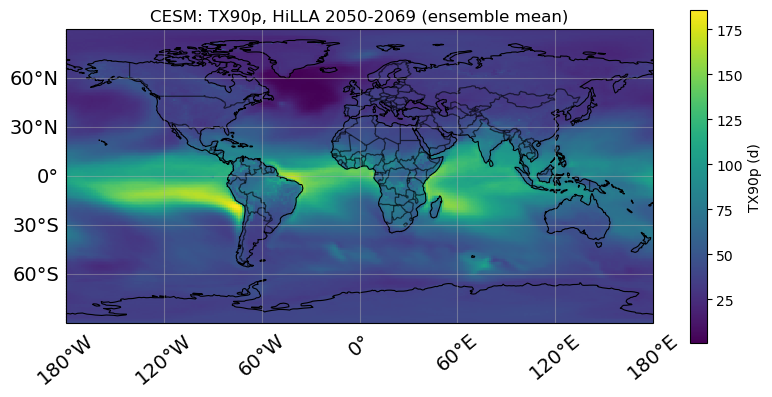

In [5]:
%%time
# --- Optional quick-look maps -----------------------------------------------
#
# Set SAVE_PLOTS = True in the choices cell to write each panel as a PNG.
#
if MAKE_PLOT:
    import cartopy.crs as crs
    import cartopy.feature as cfeature
    from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

    if SAVE_PLOTS:
        os.makedirs(PLOT_DIR, exist_ok=True)

    def _savefig(fig, stem):
        if SAVE_PLOTS:
            path = os.path.join(PLOT_DIR, stem + '.png')
            fig.savefig(path, dpi=PLOT_DPI, bbox_inches='tight', facecolor='white')
            print(f'  saved {path}')

    def _style_geo(ax, left=True, bottom=True):
        # add coastlines, borders, gridlines, lon and lat labels
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS.with_scale('110m'), linewidth=0.9, alpha=0.6)
        gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False, alpha=0.45)
        gl.top_labels = gl.right_labels = False
        gl.left_labels = left
        gl.bottom_labels = bottom
        gl.xformatter = LONGITUDE_FORMATTER
        gl.yformatter = LATITUDE_FORMATTER
        gl.xlabel_style = {'fontsize': 14, 'rotation':40}
        gl.ylabel_style = {'fontsize': 14}

    for model, r in results.items():
        da = r['ens_mean']
        units = da.attrs.get('units', '')
        long_name = da.attrs.get('long_name', INDEX)

        if 'month' in da.dims:
            # -------- monthly climatology: one map per calendar month --------
            proj = crs.PlateCarree()
            fg = da.plot(
                col='month', col_wrap=3,
                cmap='viridis',
                transform=proj,
                subplot_kws={'projection': proj},
                cbar_kwargs={'label': f'{INDEX} ({units})', 'shrink': 0.65},
                figsize=(20, 10.5),
            )
            month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                           'Jul','Aug','Sep','Oct','Nov','Dec']
            # xarray renamed FacetGrid.axes to .axs in 2022.11; support both.
            grid_axes = np.atleast_2d(getattr(fg, 'axs', getattr(fg, 'axes', None)))
            nrow, ncol = grid_axes.shape
            flat = np.ravel(grid_axes)
            months = da['month'].values
            for pos, (ax, m) in enumerate(zip(flat, months)):
                row, col = divmod(pos, ncol)
                # left labels only on the first column; bottom labels only on
                # the last panel of each column, which for a full grid is the
                # bottom row and for a short final row is the panel above the gap.
                is_last_in_col = (pos + ncol >= len(months))
                _style_geo(ax, left=(col == 0), bottom=is_last_in_col)
                ax.set_title(month_names[int(m) - 1], fontsize=16)
            fg.fig.patch.set_facecolor('white')
            fg.fig.suptitle(f'{model}: {long_name}, {SCENARIO} '
                            f'{ASSESS.start_year}-{ASSESS.end_year} '
                            f'(ensemble mean, monthly climatology)',
                            y=1.02, fontsize=18)
            # fg.fig.subplots_adjust(wspace=-0.05)
            _savefig(fg.fig, f'{INDEX}_{model}_{SCENARIO}_{ASSESS.start_year}-{ASSESS.end_year}_monthly_maps')
            plt.show()

            # -------- area-mean seasonal cycle, cos-lat weighted -------------
            # Per hemisphere as well as globally: the hemispheres are half a
            # year out of phase, so a global mean cancels most of the signal.
            w = np.cos(np.deg2rad(da['lat']))
            fig, ax = plt.subplots(figsize=(6.6, 3.6))
            fig.patch.set_facecolor('white')
            for lab, sub in (('global', da),
                             ('NH', da.where(da['lat'] >= 0)),
                             ('SH', da.where(da['lat'] < 0))):
                cyc = sub.weighted(w.where(np.isfinite(sub.isel(month=0)), 0)
                                   ).mean(('lat', 'lon'))
                ax.plot(cyc['month'], cyc.values, marker='o', label=lab)
            ax.set_xlabel('month')
            ax.set_ylabel(f'{INDEX} ({units})')
            ax.set_xticks(range(1, 13))
            ax.set_title(f'{model}: area-mean seasonal cycle (cos-lat weighted)')
            ax.legend(); ax.grid(alpha=0.4)
            plt.tight_layout()
            _savefig(fig, f'{INDEX}_{model}_{SCENARIO}_{ASSESS.start_year}-{ASSESS.end_year}_seasonal_cycle')
            plt.show()

        else:
            # -------- single annual / seasonal map ---------------------------
            proj = crs.PlateCarree()
            fig = plt.figure(figsize=(8.2, 4.6))
            fig.patch.set_facecolor('white')
            ax = plt.axes(projection=proj)
            da.plot(ax=ax, cmap='viridis', transform=proj,
                    cbar_kwargs={'label': f'{INDEX} ({units})', 'shrink': 0.8})
            _style_geo(ax)
            season = {'YS': '', 'QS-DEC': ' DJF'}.get(FREQ, '')
            ax.set_title(f'{model}: {long_name}{season}, {SCENARIO} '
                         f'{ASSESS.start_year}-{ASSESS.end_year} (ensemble mean)')
            plt.tight_layout()
            _savefig(fig, f'{INDEX}_{model}_{SCENARIO}_{ASSESS.start_year}-{ASSESS.end_year}_map')
            plt.show()

In [5]:
# --- Optional: write per-member annual fields to the shared S3 layout -------
# Uses the pipeline writer, so files land in the same tree as the released
# dataset: {root}/{model}/{scenario}/{member}/{INDEX}.nc
# The writer takes the same frequency, season, members and baseline as the
# computation above. Passing them matters: without freq and season a QS-DEC run
# would write into the annual tree, and without baseline_period a run on a
# non-default window would be written as though it used the released one.
if SAVE_TO_BUCKET:
    for model in models:
        paths = write_index_dataset(
            model, INDEX,
            scenarios=(SCENARIO,),
            members_by_scenario=({SCENARIO: tuple(MEMBERS)} if MEMBERS else None),
            freq=FREQ,
            season=(SEASON if FREQ == 'QS-DEC' else None),
            baseline_period=BASELINE)
        for p in paths:
            print('wrote', p)
else:
    print('SAVE_TO_BUCKET is False: nothing written. Flip it above to share '
          'this configuration.')

SAVE_TO_BUCKET is False: nothing written. Flip it above to share this configuration.


## Extending to a new indicator (ecological, agricultural, ...)

The registry pattern makes new indicators one dictionary entry. An indicator
needs: the daily variable it reads (`pr`, `tasmax`, `tasmin`), the percentile
(or a fixed threshold via the companion fixed-index repo), and the xclim
function that turns daily values plus a threshold into the index. For example,
a growing-degree or frost-day style indicator on `tasmin` follows exactly the
`TN10p` template. Add the entry to `INDEX_REGISTRY` in `multimodel_etccdi.py`,
and this notebook picks it up with no other change: it will appear in the
printed index list and every cell works as before.

If your indicator needs a variable the loaders do not yet carry (e.g. wind or
humidity), that is a loader addition rather than a registry entry: speak to
the pipeline maintainers and we will wire the variable through the per-model
layouts.

## Troubleshooting

- **`FileNotFoundError` on load:** the scenario/member combination is not on
  the archives for that model (e.g. no SAI winds outside CESM; UKESM SSP2-4.5
  sea-level pressure carries two members). The error message names the path
  it looked for.
- **Memory pressure with many members:** run one model at a time because results
  accumulate in the `results` dict across runs of the compute cell if you
  change `MODELS` between runs.
- **E3SM first-run slowness:** that is the one-time regrid+cache; subsequent
  runs stream the merged file from the bucket.
